# Dask Exercise 1: switching from `pandas`

**Dask intro**
* [Why Dask?](https://docs.dask.org/en/stable/why.html)
* [10 min to Dask](https://docs.dask.org/en/stable/10-minutes-to-dask.html)
* [Dask dataframe](https://docs.dask.org/en/stable/dataframe.html) -- scope of what is easily ported from `pandas` vs what might be slow / not implemented in Dask.
* [Dask and parquets](https://docs.dask.org/en/stable/dataframe-parquet.html)
* [Dask tutorial](https://tutorial.dask.org/01_dataframe.html) on dataframes

The first and easiest step in starting to use `dask` is to make the switch from `pandas` dataframes (dfs) to `dask` dataframes (ddfs) and find the equivalent methods. The look and feel of this should be very familiar.

The **major** difference between `pandas` dfs and `dask` ddfs is that ddfs are not read into memory. The schema and certain attributes of the df are there, but to actually get computations, you have call `.compute()`. Dask uses a lazy evaluation, which means it's storing the steps and the order you want to do it in, and evaluating it all at once when you say you want it.

|  current    | dask |    
|-------------|-----------------------|
| pandas      | dask dataframes       | 
| numpy       | dask arrays           |
| delayed     | general; loops        |


Skills:
* equivalent methods for dask dataframes
* task graphs
* concatenation
* merges
* partitioned parquets

In [1]:
import dask.dataframe as dd
import dask_geopandas as dg
import geopandas as gpd
import pandas as pd

TAXI_DATA = ("https://raw.githubusercontent.com/mwaskom/"
             "seaborn-data/master/taxis.csv"
            )

### Basics

Most `pandas` methods can be called, but you need to add a `.compute()`.

To convert a ddf to a df, simply use `ddf.compute()`. 

Alternatively, you can change any df to a ddf.

In [2]:
df = pd.read_csv(TAXI_DATA)

ddf = dd.from_pandas(df, npartitions=1)

In [3]:
ddf = dd.read_csv(TAXI_DATA)
ddf

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
npartitions=1,,,,,,,,,,,,,,
,object,object,int64,float64,float64,float64,float64,float64,object,object,object,object,object,object
,...,...,...,...,...,...,...,...,...,...,...,...,...,...


In [4]:
ddf.columns

Index(['pickup', 'dropoff', 'passengers', 'distance', 'fare', 'tip', 'tolls',
       'total', 'color', 'payment', 'pickup_zone', 'dropoff_zone',
       'pickup_borough', 'dropoff_borough'],
      dtype='object')

In [5]:
ddf.dtypes

pickup              object
dropoff             object
passengers           int64
distance           float64
fare               float64
tip                float64
tolls              float64
total              float64
color               object
payment             object
pickup_zone         object
dropoff_zone        object
pickup_borough      object
dropoff_borough     object
dtype: object

In [6]:
ddf.describe().compute()

,passengers,distance,fare,tip,tolls,total
count,6433.000000,6433.000000,6433.000000,6433.00000,6433.000000,6433.000000
mean,1.539251,3.024617,13.091073,1.97922,0.325273,18.517794
std,1.203768,3.827867,11.551804,2.44856,1.415267,13.815570
min,0.000000,0.000000,1.000000,0.00000,0.000000,1.300000
25%,1.000000,0.980000,6.500000,0.00000,0.000000,10.800000
50%,1.000000,1.640000,9.500000,1.70000,0.000000,14.160000
75%,2.000000,3.210000,15.000000,2.80000,0.000000,20.300000
max,6.000000,36.700000,150.000000,33.20000,24.020000,174.820000


In [7]:
# df.shape or len(df) would not work
# to find how many rows there are, find the length of the index
len(ddf.index)

6433

### Cleaning Columns / Apply Row-Wise Functions  

For the most part, this is intact. Sometimes there is a `dask` equivalent of the `pandas` methods. Always look to see if there is one first.

In [8]:
# Lambda functions in pandas
df = df.assign(
    same_borough = df.apply(
        lambda x: 
        1 if x.pickup_borough == x.dropoff_borough
        else 0, axis=1)
)

In [9]:
# Apply the same lambda function for dask df
# Make sure to add the metadata argument to specify the data type
ddf = ddf.assign(
    same_borough = ddf.apply(
        lambda x:
        1 if x.pickup_borough == x.dropoff_borough
        else 0, axis=1, meta=('same_borough', 'int')
    )
)

In [10]:
ddf.same_borough.value_counts().compute()

1    5582
0     851
Name: same_borough, dtype: int64

In [11]:
def type_of_trip(row) -> str: 
    if ((row.passengers == 1) and 
        (row.distance >= 5) and 
        (row.pickup_borough != row.dropoff_borough)
       ):
        return "individual_long_trips"
    elif ((row.passengers > 1) and 
          (row.distance >= 5) and 
          (row.pickup_borough != row.dropoff_borough)
    ):
        return "group_long_trips"
    
    else:
        return "short_trips"
        

In [12]:
ddf = ddf.assign(
    trip_type = ddf.apply(
        lambda x: type_of_trip(x), 
        axis=1, meta=("trip_type", "str"))
)

In [13]:
ddf.groupby("trip_type").agg(
    {"total": "sum", 
     "passengers": "sum"}).reset_index().compute()

,trip_type,total,passengers
0,short_trips,88220.44,8917
1,individual_long_trips,23164.23,482
2,group_long_trips,7740.30,503


### DateTimes

A lot of the methods are similar here!

In [14]:
ddf = ddf.assign(
    pickup_time = dd.to_datetime(ddf.pickup),
    pickup_hour = dd.to_datetime(ddf.pickup).dt.hour
)

In [15]:
ddf.pickup_hour.value_counts().compute()

18    417
19    406
17    388
20    368
14    360
21    355
16    336
12    334
15    330
10    325
22    321
9     319
13    316
8     313
23    296
11    295
7     221
0     205
6     142
1     110
2     101
3      67
4      57
5      51
Name: pickup_hour, dtype: int64

## Task Graphs

Since Dask is lazily evaluated, it's really just storing the order of operations for you. To see all the transformations you're doing to the dataframe, look at the task graph.

In [16]:
# Split up the ddf into multiple partitions
ddf2 = ddf.repartition(npartitions=5)

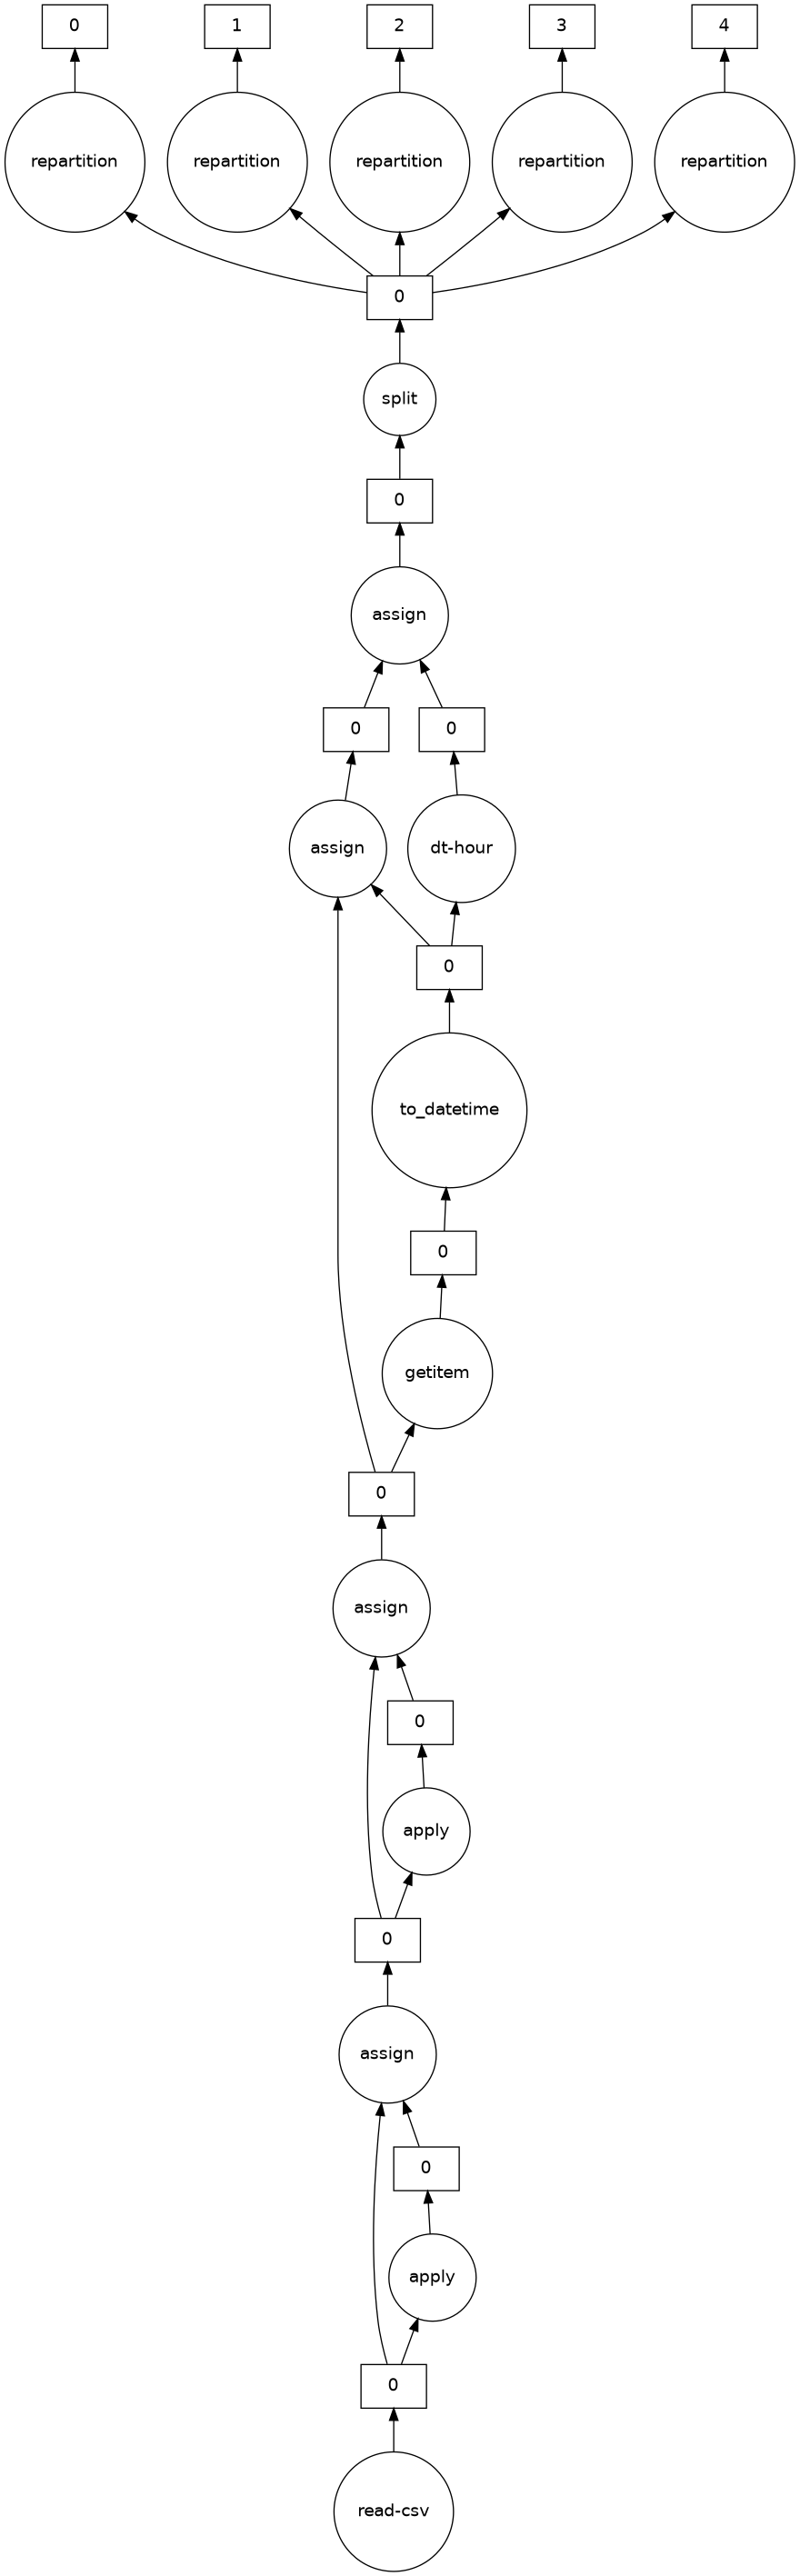

In [17]:
ddf2.visualize()

## Concatenation

Instead of `pd.concat`, use `dd.multi.concat`. [Docs](https://docs.dask.org/en/stable/generated/dask.dataframe.multi.concat.html).

The fact that we are concatenating a list of dfs or ddfs is a very useful concept to use in `dask.delayed`.

In [18]:
yellow = df[df.color=="yellow"].reset_index(drop=True)
green = df[df.color=="green"].reset_index(drop=True)

yellow_ddf = dd.from_pandas(yellow, npartitions=1)
green_ddf = dd.from_pandas(green, npartitions=1)

In [19]:
combined_df = pd.concat([yellow, green], axis=0)
combined_df.shape

(6433, 15)

In [20]:
combined_ddf = dd.multi.concat([yellow_ddf, green_ddf], axis=0)
len(combined_ddf.index)

6433

## Merges

This isn't a very meaningful merge, but we'll use it to demonstrate anyway.

Let's say that there's a column called `manhattan_flag` in `yellow_ddf` and we want to bring that column in for `green_ddf`. 

We cannot use the `validate` parameter in the merge, but most of the other arguments are present. [Docs](https://docs.dask.org/en/stable/generated/dask.dataframe.DataFrame.merge.html).

In [21]:
# Not that this is a meaningful merge, but, we can!
yellow_ddf = yellow_ddf.assign(
    manhattan_flag = yellow_ddf.apply(
        lambda x: 
        1 if (x.pickup_borough == "Manhattan") or 
        (x.dropoff_borough=="Manhattan") 
         else 0, axis=1, meta=("manhattan_flag", "int")
    )
)

yellow_ddf


,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough,same_borough,manhattan_flag
npartitions=1,,,,,,,,,,,,,,,,
0,object,object,int64,float64,float64,float64,float64,float64,object,object,object,object,object,object,int64,int64
5450,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


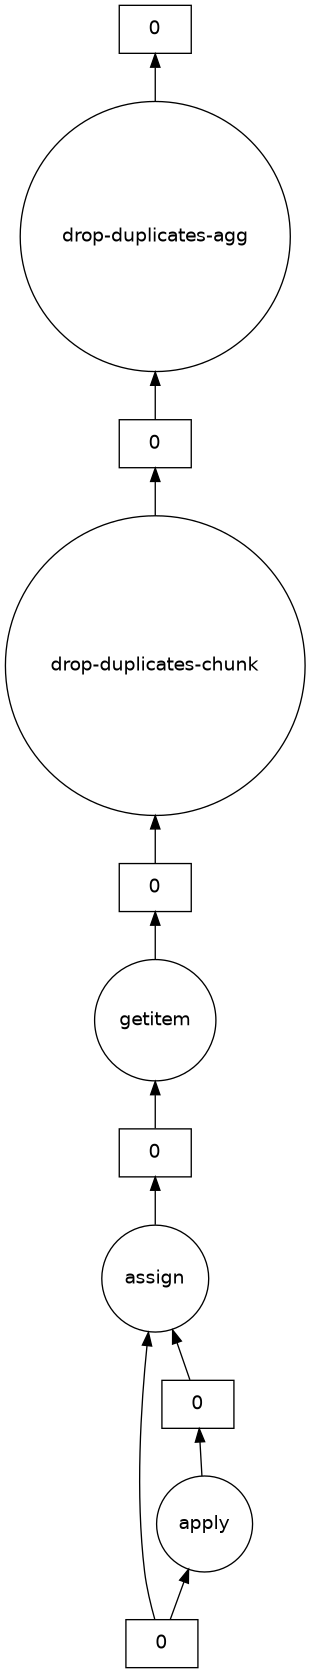

In [22]:
yellow_ddf_flag = yellow_ddf[["pickup_borough", "dropoff_borough", 
                              "manhattan_flag"]].drop_duplicates()

yellow_ddf_flag.visualize()

In [23]:
m1 = dd.merge(
    green_ddf,
    yellow_ddf_flag,
    on = ["pickup_borough", "dropoff_borough"],
    how = "inner"
)

In [24]:
m1.manhattan_flag.value_counts().compute()

0    600
1    378
Name: manhattan_flag, dtype: int64

## Partitioned Parquets

We already use parquets because it's a lot faster than csv or geojson. We can also use partitioned parquets (a folder of lots of smaller parquet files).

The folder of partitioned parquets can be easily read back in or filtered against.

If you find that the `.compute()` step in bringing a very large ddf into memory is holding you back, consider exporting it out as a partitioned parquet. Reading a partitioned parquet back in and exporting as a single parquet is faster.

In [25]:
type(ddf.compute())

pandas.core.frame.DataFrame

In [26]:
type(ddf)

dask.dataframe.core.DataFrame

In [27]:
# We don't have trouble computing and bringing this back into memory
ddf.compute()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough,same_borough,trip_type,pickup_time,pickup_hour
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan,1,short_trips,2019-03-23 20:21:09,20
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan,1,short_trips,2019-03-04 16:11:55,16
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan,1,short_trips,2019-03-27 17:53:01,17
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan,1,short_trips,2019-03-10 01:23:59,1
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan,1,short_trips,2019-03-30 13:27:42,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6428,2019-03-31 09:51:53,2019-03-31 09:55:27,1,0.75,4.5,1.06,0.0,6.36,green,credit card,East Harlem North,Central Harlem North,Manhattan,Manhattan,1,short_trips,2019-03-31 09:51:53,9
6429,2019-03-31 17:38:00,2019-03-31 18:34:23,1,18.74,58.0,0.00,0.0,58.80,green,credit card,Jamaica,East Concourse/Concourse Village,Queens,Bronx,0,individual_long_trips,2019-03-31 17:38:00,17
6430,2019-03-23 22:55:18,2019-03-23 23:14:25,1,4.14,16.0,0.00,0.0,17.30,green,cash,Crown Heights North,Bushwick North,Brooklyn,Brooklyn,1,short_trips,2019-03-23 22:55:18,22
6431,2019-03-04 10:09:25,2019-03-04 10:14:29,1,1.12,6.0,0.00,0.0,6.80,green,credit card,East New York,East Flatbush/Remsen Village,Brooklyn,Brooklyn,1,short_trips,2019-03-04 10:09:25,10


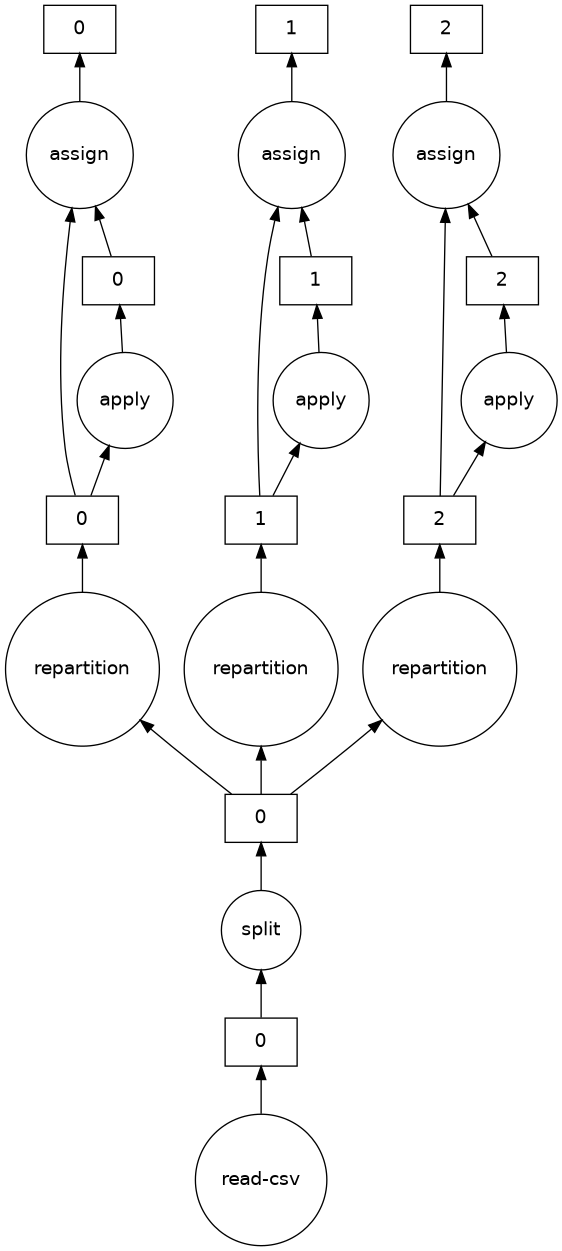

In [28]:
# Look at this task graph
ddf3 = dd.read_csv(TAXI_DATA).repartition(npartitions=3)
ddf3 = ddf3.assign(
    trip_type = ddf3.apply(
        lambda x: type_of_trip(x), 
        axis=1, meta=("trip_type", "str"))
)

ddf3.visualize()

In [29]:
ddf3

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough,trip_type
npartitions=3,,,,,,,,,,,,,,,
,object,object,int64,float64,float64,float64,float64,float64,object,object,object,object,object,object,object
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


In [30]:
# look at the format of this partitioned parquet
ddf3.to_parquet("dask1_multipart", overwrite=True)

In [31]:
read_in_ddf3 = dd.read_parquet("dask1_multipart/")
read_in_ddf3

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough,trip_type
npartitions=3,,,,,,,,,,,,,,,
,object,object,int64,float64,float64,float64,float64,float64,object,object,object,object,object,object,object
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


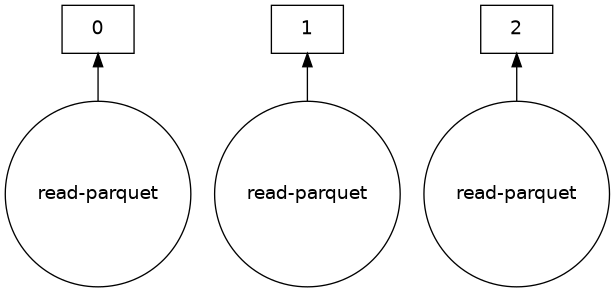

In [32]:
# task graph just reads in each part
read_in_ddf3.visualize()

## To Do

* Import the `stop_times` parquet using dask
* Grab the hour from the `arrival_sec` column
* For each operator, calculate the number of trips per stop occurring each hour 
* Now group the individual hours into peak and off peak periods. Use 8am-10am AM Peak and 4pm-7pm PM Peak. Combine these two peak periods into one.
* Create a table of hourly trips per stop **and** peak vs offpeak trips per stop. Only display these tables for 2 operators of your choice (subset at the end).
* Use the equivalent dask dataframe methods and only compute results in the last step.
* Show the task graph at the end

In [33]:
GCS_FILE_PATH = ("gs://calitp-analytics-data/data-analyses/"
                 "rt_delay/compiled_cached_views/"
                )

analysis_date = "2023-01-18"

stop_times = dd.read_parquet(
    f"{GCS_FILE_PATH}st_{analysis_date}.parquet", 
    columns = ["feed_key", "trip_id", "stop_id", 
               "stop_sequence", "arrival_sec"]
)

In [34]:
stop_times.dtypes

feed_key         object
trip_id          object
stop_id          object
stop_sequence     int64
arrival_sec       int64
dtype: object

In [35]:
AM_PEAK_START = 8
AM_PEAK_END = 10
PM_PEAK_START = 16
PM_PEAK_END = 19
stop_times["stop_unique_id"] = stop_times["feed_key"] + stop_times["stop_id"]
stop_times["hour"] = (stop_times["arrival_sec"] / 3600).astype(int)
stop_times["peak"] = (
    ((stop_times["hour"] >= AM_PEAK_START) & (stop_times["hour"] < AM_PEAK_END)) | 
    ((stop_times["hour"] >= PM_PEAK_START) & (stop_times["hour"] < PM_PEAK_END))
)
stop_times["off_peak"] = ~stop_times["peak"]

feed_key_by_id = stop_times[["stop_unique_id", "feed_key"]].dropna().drop_duplicates().set_index("stop_unique_id")

In [36]:
stop_times.dtypes

feed_key          object
trip_id           object
stop_id           object
stop_sequence      int64
arrival_sec        int64
stop_unique_id    object
hour               int64
peak                bool
off_peak            bool
dtype: object

In [37]:
peak_trips = stop_times.groupby("stop_unique_id").agg(
    {
        "peak": "sum",
        "off_peak": "sum",
    }
).merge(
    feed_key_by_id,
    left_index=True,
    right_index=True
)
peak_trips.compute()

,peak,off_peak,feed_key
stop_unique_id,,,
48138ae7269d615d5509958097039bf71140,12,25,48138ae7269d615d5509958097039bf7
48138ae7269d615d5509958097039bf71161,5,8,48138ae7269d615d5509958097039bf7
48138ae7269d615d5509958097039bf71153,18,42,48138ae7269d615d5509958097039bf7
48138ae7269d615d5509958097039bf71437,8,17,48138ae7269d615d5509958097039bf7
d4642902c43d526677dff02b09342b78601,10,6,d4642902c43d526677dff02b09342b78
...,...,...,...
fdf54bff79f705767670a13db867d3f7831212,1,0,fdf54bff79f705767670a13db867d3f7
fdf54bff79f705767670a13db867d3f7832122,0,1,fdf54bff79f705767670a13db867d3f7
fdf54bff79f705767670a13db867d3f7831232,0,2,fdf54bff79f705767670a13db867d3f7


In [38]:
hourly_trips = stop_times.categorize(
    columns=["hour"]
).pivot_table(
    index="stop_unique_id", columns="hour", values="arrival_sec", aggfunc="count"
).merge(
    feed_key_by_id,
    left_index=True,
    right_index=True
)
hourly_trips.compute()

,0,1,2,3,4,5,6,7,8,9,...,17,18,19,20,21,22,23,24,25,feed_key
stop_unique_id,,,,,,,,,,,,,,,,,,,,,
008d5112a7e531d0562d26e34d77869d1000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,008d5112a7e531d0562d26e34d77869d
008d5112a7e531d0562d26e34d77869d1001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,008d5112a7e531d0562d26e34d77869d
008d5112a7e531d0562d26e34d77869d1002,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,008d5112a7e531d0562d26e34d77869d
008d5112a7e531d0562d26e34d77869d1003,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,008d5112a7e531d0562d26e34d77869d
008d5112a7e531d0562d26e34d77869d1004,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,008d5112a7e531d0562d26e34d77869d
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ffe4d3c164a4ea75fac457d7499dca375472,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,ffe4d3c164a4ea75fac457d7499dca37
ffe4d3c164a4ea75fac457d7499dca375473,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,ffe4d3c164a4ea75fac457d7499dca37
ffe4d3c164a4ea75fac457d7499dca37767640,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,ffe4d3c164a4ea75fac457d7499dca37


In [39]:
#%%timeit
stops_trips_per_hour.dtypes

NameError: name 'stops_trips_per_hour' is not defined